# **[W3] Pilot Task**



## **데이터 기본 정보**

**<데이터 개요>**
- 사용 데이터: **Kaggle: Predict Customer Churn**

- URL: https://www.kaggle.com/competitions/playground-series-s6e3/overview

- 목표: 고객 이탈 가능성 예측

- 평가 지표: ROC

---

**<데이터 구성>**
- train.csv: 학습용 데이터, 594,194행
- test.csv: 평가용 데이터, 254,651행
- sample_submission.csv: 제출 예시.(본 분석에서는 필요하지 않음)

In [11]:
# 기본 설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [12]:
# 모델
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, classification_report

In [13]:
# 데이터 불러오기
train = pd.read_csv('train_proc (1).csv')
test = pd.read_csv('test_proc (1).csv')
test_id = pd.read_csv('test_id (1).csv')

## **(TASK1) 모델링**

1. 문제 유형: 분류(Binary Classification)

2. 사용 모델
    - Random Forest: 기본적인 성능 파악
    - XGBoost: 정형 데이터 예측 강세

3. 하이퍼 파라미터
    - Random Forest: 별도 설정 미진행
    - XGBoost:
        - `n_estimators`: 500(적당한 수준의 학습 유도)
        - `learning_rate`: 0.05 (세밀한 패턴 학습 유도)
        - `max_depth`: 6 (과적합 방지)

In [14]:
# target 분리
X = train.drop('Churn', axis=1)
y = train['Churn']

In [15]:
# 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Random Forest

In [17]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

### XGBoost

In [ ]:
# 기본
xgb_model = XGBClassifier(n_estimators=500,
                          learning_rate=0.05,
                          max_depth=6,
                          random_state=42,
                          eval_metric='auc')
xgb_model.fit(X_train, y_train)

In [18]:
# 하이퍼파라미터 튜닝
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50 # 성능 개선 없으면 조기 종료
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

[0]	validation_0-auc:0.90624
[100]	validation_0-auc:0.91436
[200]	validation_0-auc:0.91571
[300]	validation_0-auc:0.91630
[400]	validation_0-auc:0.91651
[500]	validation_0-auc:0.91660
[600]	validation_0-auc:0.91666
[700]	validation_0-auc:0.91668
[751]	validation_0-auc:0.91667


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=50,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

### 모델 평가 및 비교

In [20]:
# ROC-AUC
def evaluate_model(model, X_v, y_v, name):
    probs = model.predict_proba(X_v)[:, 1]
    auc_score = roc_auc_score(y_v, probs)
    print(f"[{name}] ROC-AUC Score: {auc_score:.4f}")
    return probs

rf_probs = evaluate_model(rf_model, X_val, y_val, "Random Forest")
xgb_probs = evaluate_model(model, X_val, y_val, "XGBoost")

[Random Forest] ROC-AUC Score: 0.9123
[XGBoost] ROC-AUC Score: 0.9167


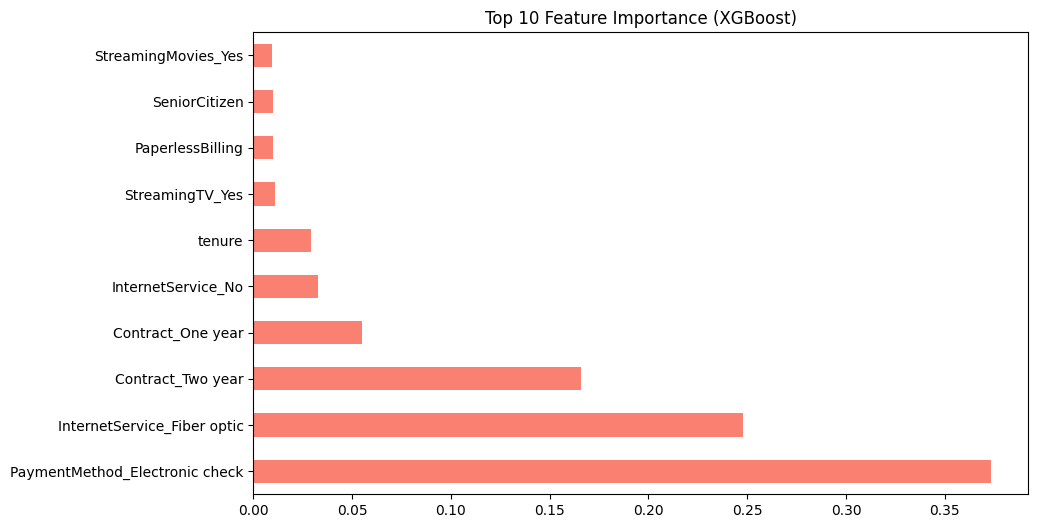

In [22]:
# 특성 중요도
plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Feature Importance (XGBoost)')
plt.show()

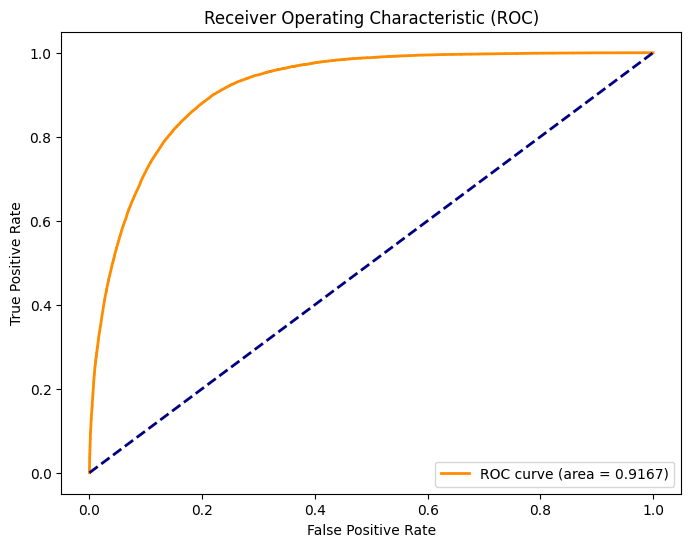

In [25]:
# ROC CURVE
from sklearn.metrics import auc

fpr, tpr, _ = roc_curve(y_val, xgb_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

<Figure size 600x500 with 0 Axes>

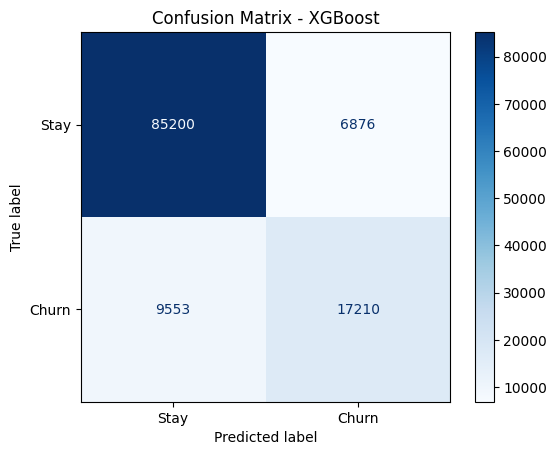

In [27]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

xgb_preds = (xgb_probs > 0.5).astype(int)
cm = confusion_matrix(y_val, xgb_preds)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Churn']).plot(cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.show()

- (TN) 85,200명은 이탈하지 않을 고객을 정확하게 예측
- (FP) 6,876명은 이탈하지 않을 고객인데, 모델이 이탈할 것으로 잘못 예측
- (FN)9,553명은 이탈할 고객인데, 모델이 이탈하지 않을 것으로 잘못 예측
- (TP)17,210명은 이탈할 고객을 정확하게 예측

## [결과]
1. 문제 유형 정의

    - 유형: 이진 분류 (Binary Classification)

    - 목표: 고객의 여러 특성을 바탕으로 이탈 여부(Churn)를 예측

2. 모델 선택 및 학습 전략
    - 사용한 모델:
        - Random Forest: 앙상블 모델의 기준 성능을 파악하기 위해 사용 (ROC-AUC: 0.9123)
        - XGBoost: 정형 데이터에서 최적의 성능을 끌어내기 위해 사용 (ROC-AUC: 0.9167)

    - 학습 방법:

        - Early Stopping: XGBoost 학습 시 50라운드 동안 성능 개선이 없으면 멈추도록 설정하여 과적합 방지

3. 모델 평가
    - 최종 성능 비교
    | 모델 | ROC-AUC Score | 비고 |
| :--- | :---: | :--- |
| Random Forest | 0.9123 | 안정적인 베이스라인 제공 |
| XGBoost | 0.9167 | 최종 최적 모델 선정 |

    - ROC-AUC(0.9167): 모델이 무작위로 고객을 뽑았을 때, 이탈할 고객을 유지할 고객보다 높은 확률로 분류해낼 확률이 약 91.7%

    - Feature Importance:
        - Contract (Two year): 장기 계약 여부가 이탈 방지에 가장 결정적인 역할
        - tenure (가입 기간): 가입 기간이 길수록 충성도가 높아짐
        - InternetService (Fiber optic): 특정 서비스 이용 여부가 이탈 확률과 밀접함
        - AvgMonthlyFee (파생 변수): 특성 합성으로 생성한 피처가 가입 기간 대비 지불액 변수가 상위권에 위치하여 예측에 크게 기여함